### ECG analysis

https://www.ohsu.edu/knight-cardiovascular-institute/understanding-heart-valve-disease
https://litfl.com/ecg-rate-interpretation/

##### Tools
| Task             | Recommended Tools            |
| ---------------- | ---------------------------- |
| File loading     | WFDB                         |
| Preprocessing    | SciPy + custom filters       |
| R-peak detection | NeuroKit2 (multi-lead aware) |
| Visualization    | Matplotlib or Plotly         |
| ML models        | PyTorch / TensorFlow         |


##### Overview

| Use Case                     | Recommended Libraries |
| ---------------------------- | --------------------- |
| Basic ECG plotting           | NumPy + Matplotlib    |
| Filtering + R-peak detection | SciPy + NeuroKit2     |
| HRV analysis                 | NeuroKit2 or HeartPy  |
| Clinical datasets            | WFDB                  |
| Real-time monitoring         | PyQtGraph             |
| Deep learning classification | PyTorch / TensorFlow  |


In [ ]:
import sys
import re
from pathlib import Path
import numpy as np

import pyqtgraph as pg
from pyqtgraph.Qt import QtCore, QtWidgets
from scipy.signal import butter, filtfilt

# ----------------------------
# Regex patterns for parsing the input text file
# ----------------------------

# Matches "Key: Value" header lines (tolerates whitespace)
# Example: "Sample Rate: 256"
HEADER_KV_RE = re.compile(r"^\s*([^:]+?)\s*:\s*(.*?)\s*$")

# Matches data lines like:
# "12:30:00,000; -4913"
# Groups:
#   1) HH:MM:SS
#   2) milliseconds
#   3) integer ECG sample value (microvolts)
DATA_RE = re.compile(r"^\s*(\d{2}:\d{2}:\d{2}),(\d{3})\s*;\s*([+-]?\d+)\s*$")


def load_ecg_txt(path: str):
    """
    Load and parse an ECG text file with a header section and a 'Data:' section.

    Expected structure:

        Signal Type: ECG2_Type
        Start Time: 29-05-2019 12:30:00
        Sample Rate: 256
        Length: 19353344
        Unit: µV

        Data:
        12:30:00,000; -4913
        12:30:00,004; -4920
        ...

    Returns:
        fs (int):
            Sampling rate in Hz. Defaults to 256 if missing/unparseable.
        start_time_str (str | None):
            Raw "Start Time" field from header (not converted to datetime here).
        values_uv (np.ndarray):
            ECG samples in microvolts (µV), float32.
    """
    header = {}   # Stores parsed header key/value pairs, normalized to lowercase keys
    values = []   # Collects integer sample values from the data section

    in_data = False  # Becomes True after we encounter the "Data:" marker

    with open(path, "r", encoding="utf-8", errors="replace") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue  # skip empty lines

            # ----------------------------
            # Parse header until we reach the data section
            # ----------------------------
            if not in_data:
                # Once we see "Data:" (or "data:"), switch to parsing samples
                if line.lower().startswith("data"):
                    in_data = True
                    continue

                # Attempt to parse a "Key: Value" header line
                m = HEADER_KV_RE.match(line)
                if m:
                    key = m.group(1).strip().lower()
                    val = m.group(2).strip()
                    header[key] = val
                continue  # keep reading until data section begins

            # ----------------------------
            # Parse data section: timestamp + sample
            # ----------------------------
            m = DATA_RE.match(line)
            if not m:
                continue  # ignore any malformed/unexpected lines

            # group(3) is the numeric sample value
            v = int(m.group(3))
            values.append(v)

    if not values:
        raise ValueError(
            "No data samples found. Check that the file contains a 'Data:' section and valid rows."
        )

    # ----------------------------
    # Extract sampling rate from header (fallback to 256 Hz)
    # ----------------------------
    # Some files might use "Sample Rate" or "SampleRate" etc.
    fs_raw = header.get("sample rate", header.get("samplerate", "256"))
    try:
        # Pull first integer from the string (handles "256 Hz", etc.)
        fs = int(re.findall(r"\d+", fs_raw)[0])
    except Exception:
        fs = 256

    # Keep start time as a string (UI display only)
    start_time_str = header.get("start time")

    # Convert list -> numpy array for fast numeric operations
    values_uv = np.asarray(values, dtype=np.float32)  # unit assumed to be microvolts (µV)
    return fs, start_time_str, values_uv


def bandpass_filter(signal, fs, lowcut=0.5, highcut=40.0, order=4):
    """
    Bandpass filters the ECG signal using a Butterworth IIR filter.

    Typical ECG preprocessing:
      - remove baseline wander (very low frequencies) -> highpass around 0.5 Hz
      - remove high-frequency noise/muscle artifacts -> lowpass around 40 Hz

    We use filtfilt() to apply the filter forward + backward:
      - eliminates phase shift (important for waveform morphology)
      - effectively doubles filter order (steeper roll-off)
    """
    nyquist = 0.5 * fs                # Nyquist frequency = fs/2
    low = lowcut / nyquist            # normalized cutoff (0..1)
    high = highcut / nyquist

    # Butterworth bandpass design (b, a are filter coefficients)
    b, a = butter(order, [low, high], btype='band')

    # Zero-phase filtering
    return filtfilt(b, a, signal)


class ECGViewer(QtWidgets.QMainWindow):
    """
    Simple ECG viewer:
      - Shows a fixed-size time window (default: 10 s)
      - Uses a horizontal scrollbar to move through the recording
      - Plots only the visible window to keep rendering fast for long files
    """
    def __init__(self, fs: int, values_uv: np.ndarray, title: str = "ECG Viewer"):
        super().__init__()
        self.fs = fs

        # Remove DC offset / baseline mean (centers signal around 0)
        # Note: This is separate from baseline wander removal (handled by bandpass)
        values_uv = values_uv - np.mean(values_uv)

        # Bandpass filter to keep the ECG frequency band of interest
        values_uv = bandpass_filter(values_uv, fs)

        self.values_uv = values_uv

        # Window size for plotting (seconds) and derived number of samples
        self.window_seconds = 10.0
        self.window_samples = int(self.window_seconds * self.fs)

        # ----------------------------
        # Build UI layout
        # ----------------------------
        central = QtWidgets.QWidget()
        self.setCentralWidget(central)
        layout = QtWidgets.QVBoxLayout(central)

        # Plot widget (pyqtgraph is very fast for real-time/large signals)
        self.plot = pg.PlotWidget()
        self.plot.setTitle(title)
        self.plot.setLabel("bottom", "Time", units="s")
        # We plot in mV for readability (input is µV)
        self.plot.setLabel("left", "Amplitude", units="mV")
        self.plot.showGrid(x=True, y=True, alpha=0.3)

        # Curve object (we update its data on scroll)
        self.curve = self.plot.plot(pen=pg.mkPen(width=1))
        layout.addWidget(self.plot)

        # Scroll bar:
        #   range: valid starting indices for a full window
        #   singleStep: how far to move per arrow key (here ~1 second)
        #   pageStep: how far to move per page step (here one full window)
        self.scroll = QtWidgets.QScrollBar(QtCore.Qt.Orientation.Horizontal)
        self.scroll.setSingleStep(self.fs)  # ~1 second of samples
        self.scroll.setPageStep(self.window_samples)
        self.scroll.setRange(0, max(0, len(self.values_uv) - self.window_samples))
        self.scroll.valueChanged.connect(self.update_plot)
        layout.addWidget(self.scroll)

        # Info label (shows sampling rate, total samples, time range displayed)
        self.info = QtWidgets.QLabel()
        layout.addWidget(self.info)

        self.resize(1200, 600)

        # Initial plot starting at sample index 0
        self.update_plot(0)

    def update_plot(self, start_idx: int):
        """
        Update the plotted window when the scrollbar changes.

        start_idx is the first sample index of the visible window.
        """
        end_idx = min(start_idx + self.window_samples, len(self.values_uv))
        window_uv = self.values_uv[start_idx:end_idx]

        # Convert µV -> mV for display
        window_mv = window_uv / 1000.0

        # Time axis for the window: 0..window_seconds
        t = np.arange(len(window_mv), dtype=np.float32) / float(self.fs)

        # Update curve data (fast; avoids re-creating plot objects)
        self.curve.setData(t, window_mv)

        # Keep x-axis fixed to 0..window_seconds (so the view doesn't "slide")
        self.plot.setXRange(0, self.window_seconds, padding=0)

        # Compute absolute times (in seconds from recording start)
        start_sec = start_idx / float(self.fs)
        end_sec = (end_idx - 1) / float(self.fs)

        self.info.setText(
            f"fs={self.fs} Hz | samples={len(self.values_uv):,} | showing {start_sec:.2f}–{end_sec:.2f} s"
        )


def find_ecg_files(root_folder: str):
    """
    Recursively find files named exactly 'ecg.txt' under root_folder.
    Returns a sorted list of Paths.
    """
    root = Path(root_folder)
    return sorted(root.rglob("ecg.txt"))


def main():
    # Folder containing patient subfolders (recursively searched)
    ROOT_FOLDER = r"C:\Users\JLOR0029\Desktop\Patients_ECG"

    # Required Qt application object (must be created before any widgets)
    app = QtWidgets.QApplication(sys.argv)

    # Locate candidate ECG files
    ecg_files = find_ecg_files(ROOT_FOLDER)

    # If none found, show a warning dialog and exit cleanly
    if not ecg_files:
        QtWidgets.QMessageBox.warning(
            None,
            "No Files Found",
            "No ecg.txt files found in the selected folder (search is recursive)."
        )
        sys.exit(0)

    # If multiple ecg.txt files exist, let the user choose which to view
    if len(ecg_files) > 1:
        items = [str(f) for f in ecg_files]
        chosen, ok = QtWidgets.QInputDialog.getItem(
            None,
            "Select ECG File",
            "Choose ecg.txt to view:",
            items,
            0,
            False
        )
        if not ok:
            sys.exit(0)
        selected_file = chosen
    else:
        selected_file = str(ecg_files[0])

    # Parse the selected file
    fs, start_time_str, values_uv = load_ecg_txt(selected_file)

    # Compose window title
    title = f"{Path(selected_file).parent.name} | {fs} Hz"
    if start_time_str:
        title += f" | Start: {start_time_str}"

    # Create and show viewer
    viewer = ECGViewer(fs=fs, values_uv=values_uv, title=title)
    viewer.show()

    # Start Qt event loop
    app.exec()


if __name__ == "__main__":
    main()


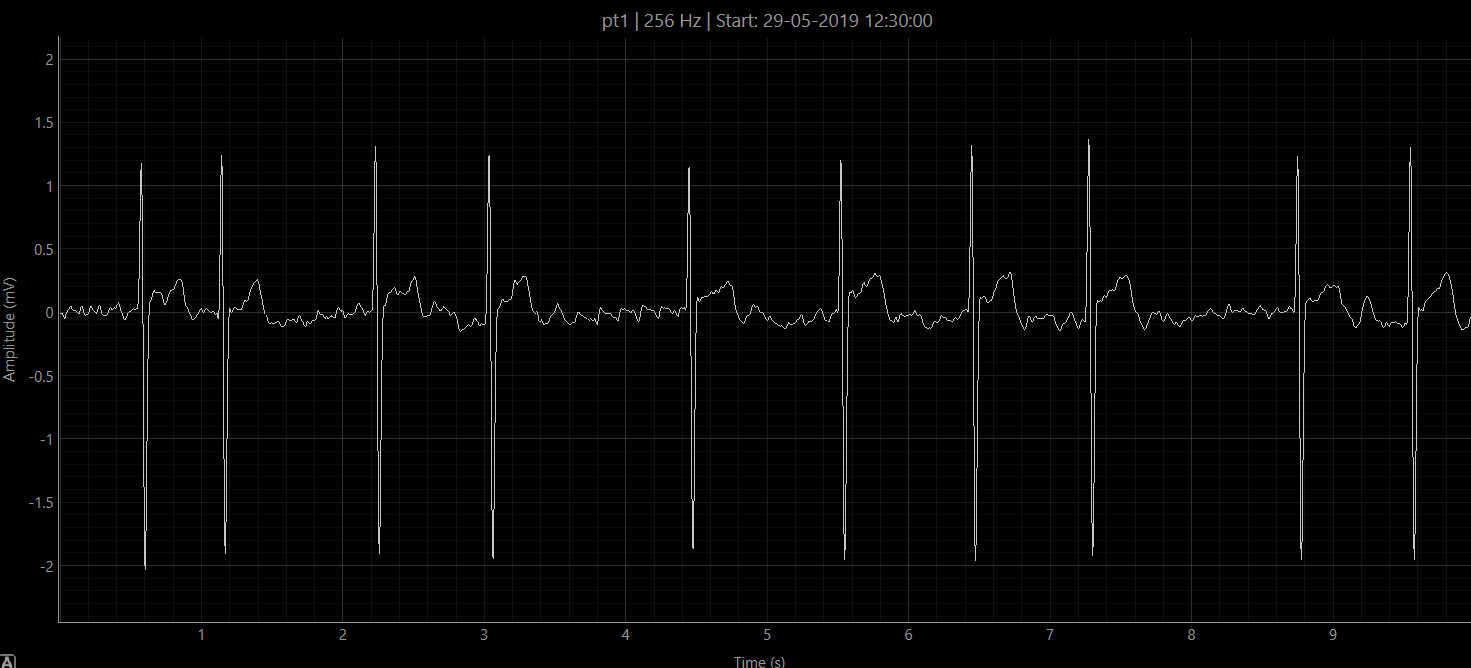